# **Load text from the web & clean them**

In [2]:
# ====== installs (run once per new runtime) ======
!pip -q install requests

# ====== imports ======
import re
import requests

# ====== helper: trim Gutenberg headers/footers ======
def trim_gutenberg(text: str) -> str:
    """
    Keep only the story by cutting away the standard Gutenberg
    header/footer between 'START OF THE PROJECT GUTENBERG EBOOK'
    and 'END OF THE PROJECT GUTENBERG EBOOK'.
    Falls back to the whole text if markers aren't found.
    """
    start_kw = "START OF THE PROJECT GUTENBERG EBOOK"
    end_kw   = "END OF THE PROJECT GUTENBERG EBOOK"
    start = text.find(start_kw)
    end   = text.find(end_kw)
    if start != -1 and end != -1 and end > start:
        return text[start + len(start_kw): end]
    return text

# ====== helper: light cleaning ======
def basic_clean(text: str) -> str:
    """
    Lowercase, replace fancy quotes/dashes, and remove non-letter characters
    except spaces and apostrophes. Collapse extra spaces.
    """
    text = text.lower()
    # normalize common unicode punctuation
    text = (text
            .replace("’", "'").replace("‘", "'")
            .replace("“", '"').replace("”", '"')
            .replace("—", "-").replace("–", "-"))
    # keep letters, spaces, apostrophes; drop digits & symbols
    text = re.sub(r"[^a-z'\s]", " ", text)
    # collapse multiple spaces/newlines
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ====== main loader ======
def load_texts(urls):
    """
    urls: list of plain-text URLs (Project Gutenberg .txt files)
    returns: dict {title: {"raw": raw_text, "trimmed": trimmed, "clean": cleaned}}
    """
    corpus = {}
    for url in urls:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        raw = r.text
        trimmed = trim_gutenberg(raw)
        clean = basic_clean(trimmed)
        # make a friendly title from the URL
        title = url.split("/")[-1]
        corpus[title] = {"raw": raw, "trimmed": trimmed, "clean": clean}
    return corpus

# ====== Lewis Carroll books (Project Gutenberg) ======
urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",      # Alice’s Adventures in Wonderland
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",      # Through the Looking-Glass
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt" # A Tangled Tale
]

corpus = load_texts(urls)

# Peek: first 200 chars of each stage for each book
for title, parts in corpus.items():
    print(f"\n=== {title} ===")
    print("RAW     :", parts["raw"][:200].replace("\n"," ") + " ...")
    print("TRIMMED :", parts["trimmed"][:200].replace("\n"," ") + " ...")
    print("CLEAN   :", parts["clean"][:200] + " ...")


=== pg11.txt ===
 most other parts of the world at no cost and with almost  ...
  CHAPTER I.     Down the Rabb ...
CLEAN   : alice's adventures in wonderland illustration alice's adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbit hole chapter ii the pool of tears chap ...

=== pg12.txt ===
 most other parts of the world at no cost and with almost no rest ...
  ...
CLEAN   : through the looking glass illustration through the looking glass and what alice found there by lewis carroll the millennium fulcrum edition dramatis person as arranged before commencement of game whit ...

=== pg29042.txt ===
 w ...
 T ...
CLEAN   : a tangled tale produced by chris curnow carla foust lindy walsh and the online distributed proofreading team at https www pgdp net music transcribed by linda cantoni transcriber's note minor punctuati ...


# **Tokenize & peek at the first tokens**

In [3]:
# Install once per runtime
!pip -q install nltk spacy

import nltk
from nltk.tokenize import word_tokenize

# First-time downloads (safe to re-run)
nltk.download('punkt')
nltk.download('punkt_tab')  # new NLTK split tables

# tokenize each CLEAN book we prepared earlier
tokens_by_book = {}
for title, parts in corpus.items():
    tokens = word_tokenize(parts["clean"])
    tokens_by_book[title] = tokens
    print(f"\n=== {title} ===")
    print(tokens[:150])  # first 150 tokens
    print(f"Total tokens: {len(tokens):,}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



=== pg11.txt ===
['alice', "'s", 'adventures', 'in', 'wonderland', 'illustration', 'alice', "'s", 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'tea', 'party', 'chapter', 'viii', 'the', 'queen', "'s", 'croquet', 'ground', 'chapter', 'ix', 'the', 'mock', 'turtle', "'s", 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alice', "'s", 'evidence', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 

# **Remove stopwords & verify**

In [4]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop = set(stopwords.words('english'))

filtered_by_book = {}
for title, tokens in tokens_by_book.items():
    filtered = [t for t in tokens if t not in stop]
    filtered_by_book[title] = filtered
    # quick verification: common stopwords should be mostly gone
    check_words = ['i','me','my','we','our','the','and']
    counts = {w: filtered.count(w) for w in check_words}
    print(f"\n=== {title} ===")
    print("Sample filtered tokens:", filtered[:40])
    print("Counts of common stopwords (should be ~0):", counts)
    print(f"Before: {len(tokens):,}  After: {len(filtered):,}")


=== pg11.txt ===
Sample filtered tokens: ['alice', "'s", 'adventures', 'wonderland', 'illustration', 'alice', "'s", 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'sends', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi']
Counts of common stopwords (should be ~0): {'i': 0, 'me': 0, 'my': 0, 'we': 0, 'our': 0, 'the': 0, 'and': 0}
Before: 27,499  After: 13,116

=== pg12.txt ===
Sample filtered tokens: ['looking', 'glass', 'illustration', 'looking', 'glass', 'alice', 'found', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'arranged', 'commencement', 'game', 'white', 'red', 'pieces', 'pawns', 'pawns', 'pieces', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyster', 'walrus'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **Stemming (Porter) preview**

In [5]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

for title, filtered in filtered_by_book.items():
    stemmed = [stemmer.stem(t) for t in filtered]
    print(f"\n=== {title} — first 50 stems ===")
    print(stemmed[:50])


=== pg11.txt — first 50 stems ===
['alic', "'s", 'adventur', 'wonderland', 'illustr', 'alic', "'s", 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter', 'viii', 'queen']

=== pg12.txt — first 50 stems ===
['look', 'glass', 'illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king', 'fawn', 'rose', 'r', 'king', 'age']

=== pg29042.txt — fir

# **Lemmatization with spaCy (more accurate)**

In [6]:
import spacy
# small English model (only need to download once per runtime)
!python -m spacy download en_core_web_sm -q
nlp = spacy.load("en_core_web_sm")

lemmatized_by_book = {}
for title, parts in corpus.items():
    # Use the TRIMMED text (keeps punctuation for spaCy sentence boundary detection)
    doc = nlp(parts["trimmed"])
    # keep alphabetic lemmas only, lowercased
    lemmas = [t.lemma_.lower() for t in doc if t.is_alpha]
    lemmatized_by_book[title] = lemmas
    print(f"\n=== {title} — first 50 lemmas ===")
    print(lemmas[:50])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 108.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

=== pg11.txt — first 50 lemmas ===
['alice', 'adventures', 'in', 'wonderland', 'illustration', 'alice', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'send', 'in', 'a', 'little', 'bill', 'chapter', 'advice', 'from', 'a']

=== pg12.txt — first 50 lemmas ===
['through', 'the', 'looking', 'glass', 'illustration', 'through

# **Spot the difference (stem vs lemma)**

In [7]:
# Compare on the same first 30 filtered tokens from the first book
first_title = list(filtered_by_book.keys())[0]
sample = filtered_by_book[first_title][:30]

stemmed_sample = [PorterStemmer().stem(t) for t in sample]
# build a tiny spaCy doc from the same sample to get lemmas
doc = nlp(" ".join(sample))
lemm_sample = [t.lemma_.lower() for t in doc if t.is_alpha]

print("Original  :", sample)
print("Stemmed   :", stemmed_sample)
print("Lemmatized:", lemm_sample)

Original  : ['alice', "'s", 'adventures', 'wonderland', 'illustration', 'alice', "'s", 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv']
Stemmed   : ['alic', "'s", 'adventur', 'wonderland', 'illustr', 'alic', "'s", 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv']
Lemmatized: ['alice', 'adventure', 'wonderland', 'illustration', 'alice', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv']


# **Quick POS tagging & NER**

In [8]:
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')  # new tagger table

# POS with NLTK on the filtered tokens
for title, filtered in filtered_by_book.items():
    pos_pairs = pos_tag(filtered[:60])  # just preview first 60 tokens
    print(f"\n=== {title} — POS preview (first 60) ===")
    print(pos_pairs)

# NER with spaCy on the trimmed text
for title, parts in corpus.items():
    doc = nlp(parts["trimmed"])
    ents = [(e.text, e.label_) for e in doc.ents[:20]]  # preview first 20 entities
    # quick entity type counts
    from collections import Counter
    counts = Counter([e.label_ for e in doc.ents])
    print(f"\n=== {title} — NER preview ===")
    print("Sample:", ents)
    print("Entity type counts (top 10):", counts.most_common(10))

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.



=== pg11.txt — POS preview (first 60) ===
[('alice', 'NN'), ("'s", 'POS'), ('adventures', 'NNS'), ('wonderland', 'VBP'), ('illustration', 'NN'), ('alice', 'NN'), ("'s", 'POS'), ('adventures', 'NNS'), ('wonderland', 'VBP'), ('lewis', 'JJ'), ('carroll', 'NN'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('contents', 'NNS'), ('chapter', 'NN'), ('rabbit', 'NN'), ('hole', 'JJ'), ('chapter', 'NN'), ('ii', 'NN'), ('pool', 'NN'), ('tears', 'NNS'), ('chapter', 'NN'), ('iii', 'VBP'), ('caucus', 'NN'), ('race', 'NN'), ('long', 'JJ'), ('tale', 'JJ'), ('chapter', 'NN'), ('iv', 'NN'), ('rabbit', 'NN'), ('sends', 'VBZ'), ('little', 'JJ'), ('bill', 'NN'), ('chapter', 'NN'), ('v', 'NN'), ('advice', 'NN'), ('caterpillar', 'JJ'), ('chapter', 'NN'), ('vi', 'NN'), ('pig', 'NN'), ('pepper', 'IN'), ('chapter', 'NN'), ('vii', 'NN'), ('mad', 'JJ'), ('tea', 'NN'), ('party', 'NN'), ('chapter', 'NN'), ('viii', 'NN'), ('queen', 'NN'), ("'s", 'POS'), ('croquet', 'NN'), ('ground', 'NN'), ('chapter',

# **Word Cloud Visualization**

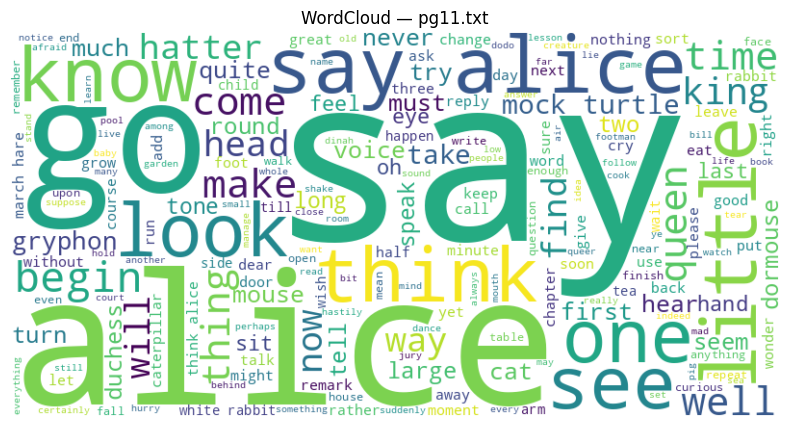

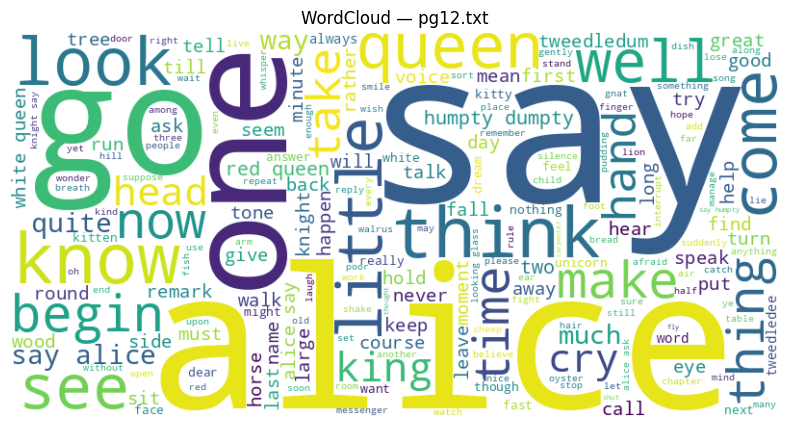

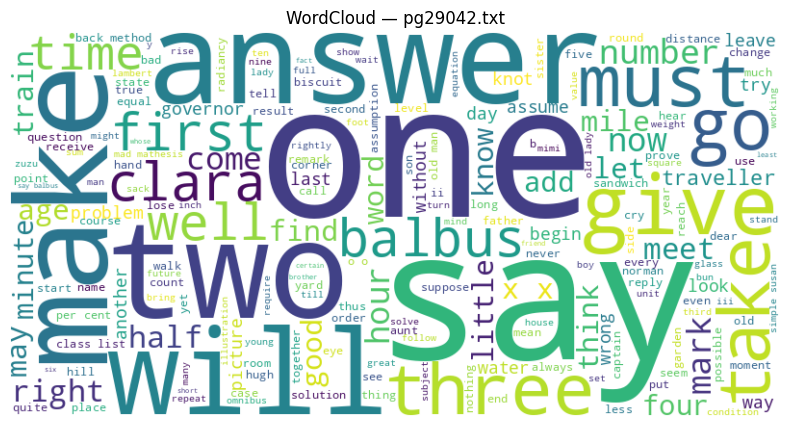

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for title, lemmas in lemmatized_by_book.items():
    text = " ".join(lemmas)
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud — {title}")
    plt.show()

# **Bags of Words (BoW)**


Top-5 BoW — pg11.txt: {'the': 1650, 'and': 872, 'be': 836, 'to': 729, 'she': 645}


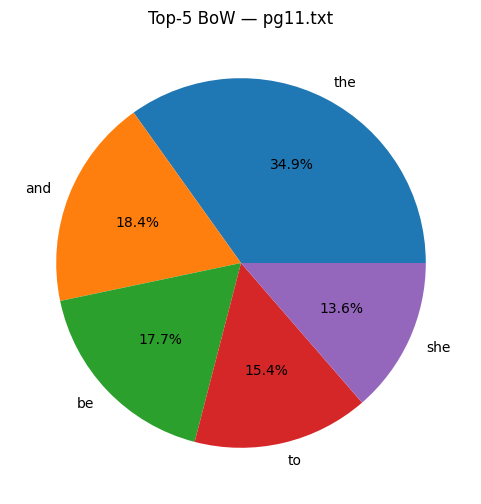


Top-5 BoW — pg12.txt: {'the': 1608, 'and': 917, 'be': 910, 'a': 767, 'to': 754}


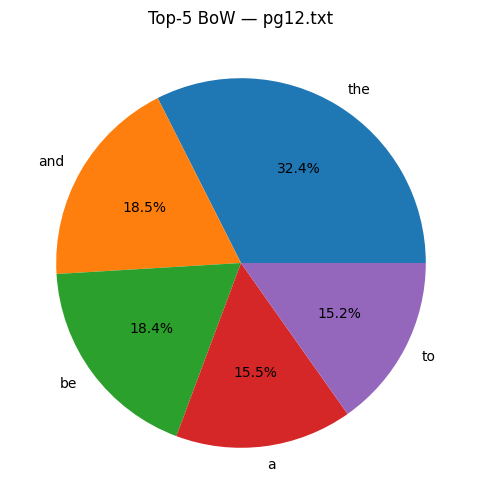


Top-5 BoW — pg29042.txt: {'the': 1736, 'be': 990, 'and': 786, 'of': 769, 'to': 619}


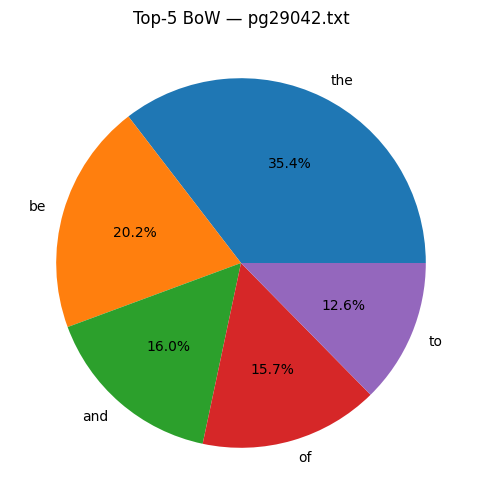

In [13]:
from collections import Counter

for title, lemmas in lemmatized_by_book.items():
    counts = Counter(lemmas)
    top = dict(counts.most_common(5))
    print(f"\nTop-5 BoW — {title}:", top)
    plt.figure(figsize=(6,6))
    plt.pie(top.values(), labels=top.keys(), autopct="%1.1f%%")
    plt.title(f"Top-5 BoW — {title}"); plt.show()

TF-IDF(Term frequency-Innverse Document Frequency) (Smarter Word Weighting)


Top-5 TF-IDF — pg11.txt: {'gryphon': 0.3333997247259246, 'rabbit': 0.3212760983722546, 'turtle': 0.28583024035182775, 'hatter': 0.2627794145170029, 'mock': 0.2627794145170029}


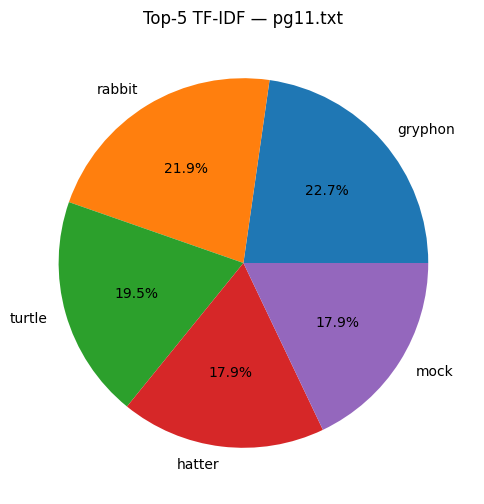


Top-5 TF-IDF — pg12.txt: {'dumpty': 0.35336435049946857, 'humpty': 0.35336435049946857, 'knight': 0.28313962686047706, 'tweedledum': 0.2334728744371489, 'tweedledee': 0.1829922529372248}


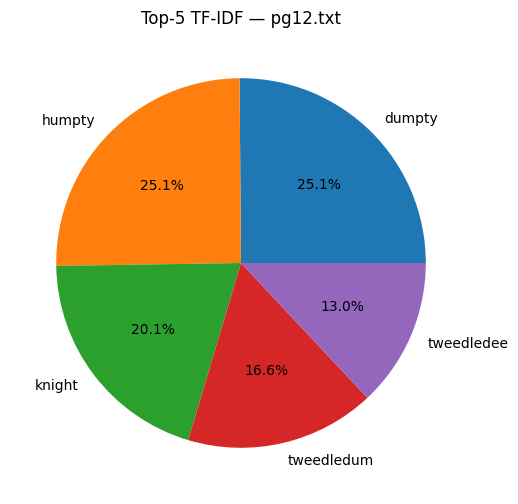


Top-5 TF-IDF — pg29042.txt: {'balbus': 0.3163431696800078, 'clara': 0.28425038435015193, 'train': 0.18479881340292, 'governor': 0.15129455941217765, 'hugh': 0.14670987579362682}


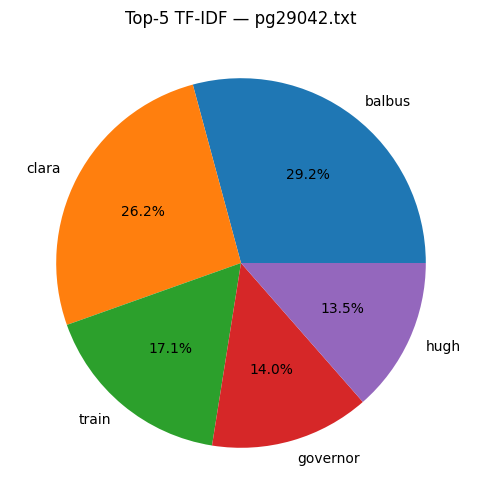

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

titles = list(lemmatized_by_book.keys())
docs   = [" ".join(lemmatized_by_book[t]) for t in titles]

vec = TfidfVectorizer(min_df=1, max_df=2)  # small corpus advice
X = vec.fit_transform(docs)
vocab = vec.get_feature_names_out()

for i, title in enumerate(titles):
    scores = X[i].toarray()[0]
    idx = np.argsort(scores)[-5:][::-1]
    top = {vocab[j]: float(scores[j]) for j in idx}
    print(f"\nTop-5 TF-IDF — {title}:", top)
    plt.figure(figsize=(6,6))
    plt.pie(top.values(), labels=top.keys(), autopct="%1.1f%%")
    plt.title(f"Top-5 TF-IDF — {title}"); plt.show()